In [1]:
%matplotlib inline

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from initial_ideas.utils.minimization_control import *
import pickle

In [4]:
# Construct ground truth model
cfm_params = {
    "fluctuations": (1,1),
    "loglogavgslope": (-3,1),
    "asperity": None,
    "flexibility": None,
    "offset_mean": 0,
    "offset_std": (1,2)
}

num_of_pixels = 2048
max_time = 1
time_domain = ift.DomainTuple.make(ift.RGSpace((num_of_pixels, ), distances=max_time/num_of_pixels), )
time_field = ift.Field(ift.DomainTuple.make(time_domain, ), val=np.linspace(0, max_time, num_of_pixels))

signal_model = ift.SimpleCorrelatedField(time_domain, **cfm_params, use_uniform_prior_on_fluctuations=False)

In [5]:
# Extract random ground truth field
signal = signal_model(ift.from_random(signal_model.domain))

In [ ]:
plt.plot(time_field.val, signal.val, "b-")
plt.xlabel("Time")
plt.ylabel("Signal value")

Now, map this into data space by applying a masking operator and noise. For starters, model the noise through a scaling operator.

In [6]:
class Mask(ift.LinearOperator):
    def __init__(self, domain, num_of_points_to_keep):
        self._domain = domain
        self._target = ift.DomainTuple.make(ift.UnstructuredDomain((num_of_points_to_keep, )))
        self._capability = self.TIMES | self.ADJOINT_TIMES

        rng = np.random.default_rng()  # create a Generator instance
        self._where_to_keep = rng.integers(low=0, high=domain.shape, size=num_of_points_to_keep)

    def apply(self, x, mode):
        self._check_input(x, mode)
        # x is a field
        if mode == self.ADJOINT_TIMES:
            values = np.zeros(self._domain.shape[0])
            values[self._where_to_keep] = x.val
            return ift.Field(self._domain, values)

        elif mode == self.TIMES:
            extract = np.array(x.val)
            idcs = np.array(self._where_to_keep)
            values = extract[idcs]
            return ift.Field(self._target, values)

num_of_data = 1000
mask = Mask(time_domain, num_of_data)
data_domain = ift.DomainTuple.make(ift.UnstructuredDomain((num_of_data, ), ))


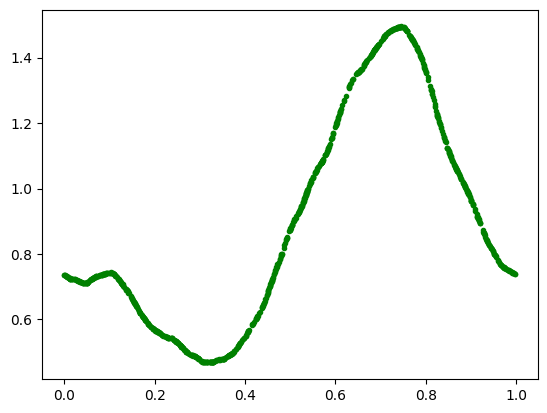

In [7]:
masked_signal_field = mask(signal)  # now of length 208
hermitianMaskedSignal = mask.adjoint(masked_signal_field)
masked_time_field = mask(time_field)
plt.plot(masked_time_field.val, masked_signal_field.val, "g.")

Now, bury this signal in noise of the same order of magnitude from a know operator

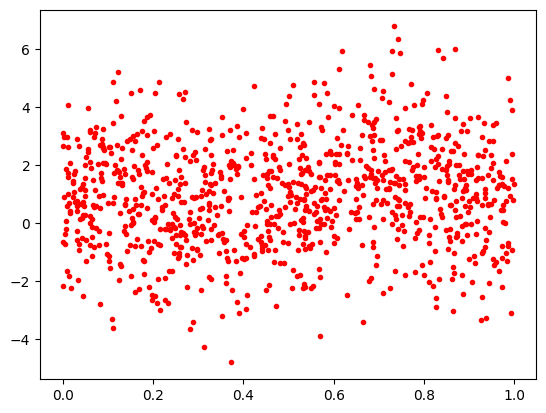

In [8]:
noise_operator = ift.ScalingOperator(data_domain, factor=3, sampling_dtype=np.float64)
estimated_noise_operator = ift.ScalingOperator(data_domain, factor=3, sampling_dtype=np.float64)
noisy_data = masked_signal_field + noise_operator.draw_sample()
plt.plot(masked_time_field.val, noisy_data.val, "r.")


## KL-optimization
It should be possible to do the reconstruction via the Wiener Filter as well as the KL optimization. Because it is faster to code, I shall do the KL optimization for now.

In [9]:
likelihood_energy = ift.GaussianEnergy(data=noisy_data, inverse_covariance=estimated_noise_operator.inverse) @ mask @ signal_model

In [10]:
global_iterations = 10

posterior_samples, final_pos = ift.optimize_kl(
                                    likelihood_energy=likelihood_energy,
                                    total_iterations=global_iterations,
                                    n_samples=kl_sampling_rate,
                                    kl_minimizer=descent_finder,
                                    sampling_iteration_controller=ic_sampling_lin,
                                    nonlinear_sampling_minimizer=geoVI_sampling_minimizer,
                                    output_directory="out_synthetic",
                                    return_final_position=True,
                                    resume=False,
                                    )

The line search algorithm (zoom) did not converge.
                     reduced χ²          mean      # dof
--------------------------------------------------------
Data residuals
  <None>              1.2 ± 0.1    -0.3 ± 0.3       1000
Latent space
  fluctuations        0.7 ± 1.0     0.2 ± 0.8          1
  loglogavgslope      1.8 ± 1.8    -0.6 ± 1.2          1
  xi                  1.0 ± 0.0    -0.0 ± 0.0       2048
  zeromode            1.4 ± 1.7     0.9 ± 0.9          1
The line search algorithm (zoom) did not converge.
                     reduced χ²          mean      # dof
--------------------------------------------------------
Data residuals
  <None>              1.1 ± 0.0    -0.0 ± 0.1       1000
Latent space
  fluctuations        0.4 ± 0.6     0.3 ± 0.6          1
  loglogavgslope      2.4 ± 2.4    -0.6 ± 1.5          1
  xi                  1.0 ± 0.0    -0.0 ± 0.0       2048
  zeromode            4.2 ± 3.4     1.9 ± 0.9          1
The line search algorithm (zoom) did not con

In [11]:

def pickle_me_this(filename: str, data_to_pickle: object):
    path = "data_storage/" + filename + ".pickle"
    file = open(path, 'wb')
    pickle.dump(data_to_pickle, file)
    file.close()


def unpickle_me_this(filename: str, absolute_path=False):
    if absolute_path:
        file = open(filename, 'rb')
    else:
        file = open("data_storage/" + filename, 'rb')
    data = pickle.load(file)
    file.close()
    return data

# posterior_samples = pickle_me_this("small_kl_run.pickle", posterior_samples)
# posterior_samples = unpickle_me_this("small_kl_run.pickle")
mean, var = posterior_samples.sample_stat(signal_model)

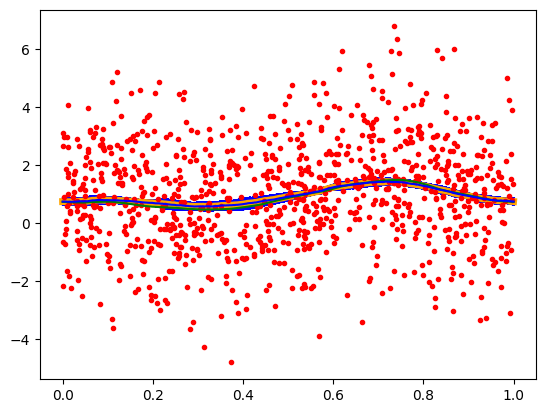

In [12]:
plt.errorbar(time_field.val, mean.val, yerr=np.sqrt(var.val), color="b", ls="-")
plt.plot(time_field.val, mean.val, color="orange", ls="-", lw=5)
plt.plot(masked_time_field.val, noisy_data.val, "r.")
plt.plot(time_field.val, signal.val, "g-")

From the corresponding python file to this jupiter notebook it can be seen that this actually works quite well given enough data points. Now, we are going to implement and benchmark the Wiener Filter solution to this problem.

## Wiener Filter

We can still take the prior correlated field ground truth but now take a k^-4 process as a prior, which fouriertransformed gives us a Gaussian.

In [19]:
def pow_spec(k):
    P0, k0, gamma = [2e6, 5, 4]
    return P0 / ((1. + (k/k0)**2)**(gamma / 2))

HT = ift.HartleyOperator(domain=time_domain)
harmonic_space = HT.target
S_fourier = ift.create_power_operator(domain=harmonic_space, power_spectrum=pow_spec, sampling_dtype=np.float64)
S_real = ift.SandwichOperator.make(bun=HT, cheese=S_fourier, sampling_dtype=np.float64)

R = mask
N = estimated_noise_operator
S = S_real
d = noisy_data

In [20]:
# Propagator
D_inv = R.adjoint @ N.inverse @ R + S.inverse

ic = ift.GradientNormController(iteration_limit=50000, tol_abs_gradnorm=0.1)
D_inv = ift.InversionEnabler(D_inv, ic)
D = D_inv.inverse

# information source
j = (R.adjoint @ N.inverse)(d)

# mean
wiener_mean = D(j)

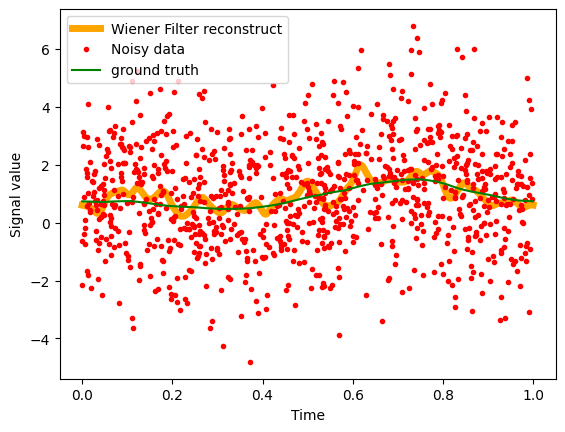

In [21]:
# plt.errorbar(time_field.val, np.sqrt(D.val), yerr=np.sqrt(var.val), color="b", ls="-")
plt.plot(time_field.val, wiener_mean.val, color="orange", ls="-", lw=5, label="Wiener Filter reconstruct")
plt.plot(masked_time_field.val, noisy_data.val, "r.", label="Noisy data")
plt.plot(time_field.val, signal.val, "g-", label="ground truth")
plt.xlabel("Time")
plt.ylabel("Signal value")
plt.legend()

I conclude that using the Wiener Filter based on some power spectrum, it is difficult to say what the fixed parameters for the fluctuations should be (and wavevector kut-off etc).

In [37]:
# Lets plot some random signal realizations
def p_s(k):
    P0, k0, gamma = [2e6, 5, 4]
    return P0 / ((1. + (k/k0)**2)**(gamma / 2))

def p_s_sqrt(k):
    P0, k0, gamma = [2e6, 5, 8]
    return np.sqrt(P0 / ((1. + (k/k0)**2)**(gamma / 2)))

HT = ift.HartleyOperator(domain=time_domain)
harmonic_space = HT.target

S_fourier = ift.create_power_operator(domain=harmonic_space, power_spectrum=p_s, sampling_dtype=np.float64)
S_fourier_sqrt = ift.create_power_operator(domain=harmonic_space, power_spectrum=p_s_sqrt, sampling_dtype=np.float64)

S_real = ift.SandwichOperator.make(bun=HT, cheese=S_fourier, sampling_dtype=np.float64)
S_real_sqrt = ift.SandwichOperator.make(bun=HT, cheese=S_fourier_sqrt, sampling_dtype=np.float64)

DomainTuple, len: 1
* RGSpace(shape=(2048,), distances=(1.0,), harmonic=True)


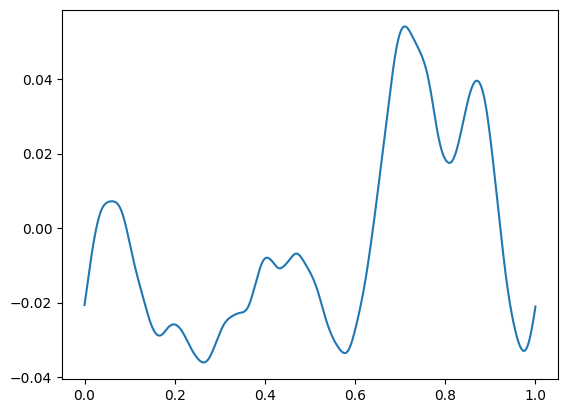

In [36]:
n = time_domain.shape[0]
mean = np.zeros(n)
cov = np.diag(np.ones(n))
# rnd = np.random.multivariate_normal(mean=mean, cov=cov)
rnd = np.random.normal(loc=0, scale=1, size=n)

xi_s = ift.Field(S_real_sqrt.domain, val=rnd)

s = S_real_sqrt(xi_s)

plt.plot(time_field.val, s.val)

n  2048
1025


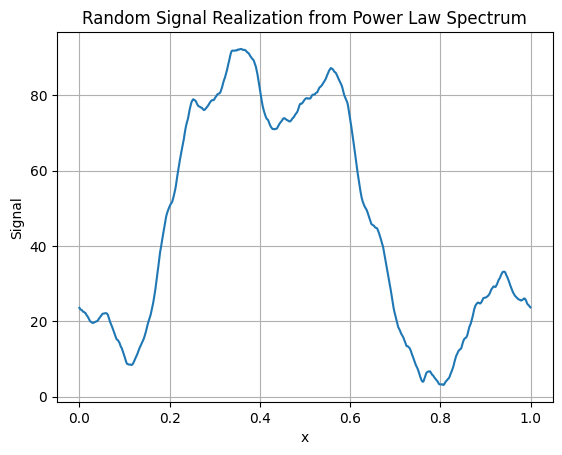

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
n = time_domain.shape[0]            # Number of points
L = 1          # Domain length
dx = L / n
k = np.fft.rfftfreq(n, d=dx) * 2 * np.pi # Angular frequencies

# Parametric power spectrum
def p_s(k):
    P0, k0, gamma = [2e10, 5, 4]
    return P0 / ((1. + (k/k0)**2)**(gamma / 2))

P_k = p_s(k)  # shape (1025,) = 1/2 n + 1 where n are the time domain points

# Generate random Fourier modes with correct amplitude
xi = np.random.normal(0, 1, len(k)) + 1j * np.random.normal(0, 1, len(k))
xi[0] = np.random.normal(0, 1)       # DC component real
xi[-1] = np.random.normal(0, 1)      # Nyquist real

# Apply sqrt power spectrum
s_k = np.sqrt(P_k) * xi

# Inverse transform to get real-space signal
s = np.fft.irfft(s_k, n=n)

# Plot
x = np.linspace(0, L, n, endpoint=False)
plt.plot(x, s)
plt.title("Random Signal Realization from Power Law Spectrum")
plt.xlabel("x")
plt.ylabel("Signal")
plt.grid()
plt.show()
